# 12 · Kaplan-Meier time-to-pain-worsening

Method from PIGD compendium (Technique 12). Survival outcome = first post-anchor visit with NP1PAIN ≥ 3 (clinically significant pain) among patients not already meeting that threshold pre-anchor. Censor at last follow-up. Stratify by DBS and by non-motor cluster (from notebook 10). Cox regression with DBS + baseline covariates.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(survival); library(survminer)
})

df <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
# Keep only post-anchor (time_pos >= 0) rows with NP1PAIN observed
post <- df %>% dplyr::filter(time_pos >= 0, !is.na(NP1PAIN))
cat("Post-anchor rows:", nrow(post), "  patients:", dplyr::n_distinct(post$PATNO), "\n")

# Exclude patients already at NP1PAIN >= 3 at their first pre-anchor window visit
pre_high <- df %>% dplyr::filter(time_pos < 0, !is.na(NP1PAIN), NP1PAIN >= 3) %>%
  dplyr::distinct(PATNO) %>% dplyr::pull(PATNO)
post <- post %>% dplyr::filter(!PATNO %in% pre_high)
cat("After excluding pre-anchor NP1PAIN≥3:", dplyr::n_distinct(post$PATNO), "patients\n")

Warning message:
“package ‘survminer’ was built under R version 4.5.2”


Post-anchor rows: 6320   patients: 170 


After excluding pre-anchor NP1PAIN≥3: 170 patients


In [2]:
# Per-patient time-to-event
ev <- post %>% dplyr::arrange(PATNO, time_pos_months) %>%
  dplyr::group_by(PATNO, will_receive_dbs) %>%
  dplyr::summarise(
    event_time = {
      hi <- which(NP1PAIN >= 3)
      if (length(hi) > 0) time_pos_months[hi[1]] else max(time_pos_months, na.rm = TRUE)
    },
    event = as.integer(any(NP1PAIN >= 3)),
    .groups = "drop"
  ) %>% dplyr::filter(is.finite(event_time), event_time > 0)
cat("KM analytic n:", nrow(ev), "  events:", sum(ev$event), "\n")
print(dplyr::count(ev, will_receive_dbs, event))
save_object(ev, "km_event_table")

KM analytic n: 145   events: 48 


# A tibble: 4 × 3
  will_receive_dbs event     n
  <lgl>            <int> <int>
1 FALSE                0    62
2 FALSE                1    26
3 TRUE                 0    35
4 TRUE                 1    22


Call: survfit(formula = survival::Surv(event_time, event) ~ will_receive_dbs, 
    data = ev)

                will_receive_dbs=FALSE 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    6     73       8    0.902  0.0331        0.839        0.969
   12     70       1    0.889  0.0348        0.823        0.960
   24     40      10    0.741  0.0523        0.646        0.851
   36     28       3    0.677  0.0595        0.570        0.804
   48     19       3    0.596  0.0685        0.476        0.747
   60     10       0    0.596  0.0685        0.476        0.747

                will_receive_dbs=TRUE 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    6     47      10    0.825  0.0504        0.732        0.929
   12     45       2    0.789  0.0540        0.690        0.903
   24     30       5    0.696  0.0618        0.585        0.828
   36     23       2    0.648  0.0662        0.530        0.791
   48     16       1    0.618  0.0695        0.496       

Call:
survival::survdiff(formula = survival::Surv(event_time, event) ~ 
    will_receive_dbs, data = ev)

                        N Observed Expected (O-E)^2/E (O-E)^2/V
will_receive_dbs=FALSE 88       26     27.8     0.123     0.303
will_receive_dbs=TRUE  57       22     20.2     0.170     0.303

 Chisq= 0.3  on 1 degrees of freedom, p= 0.6 


Log-rank p-value: 0.5821 


Ignoring unknown labels:
• colour : "Strata"


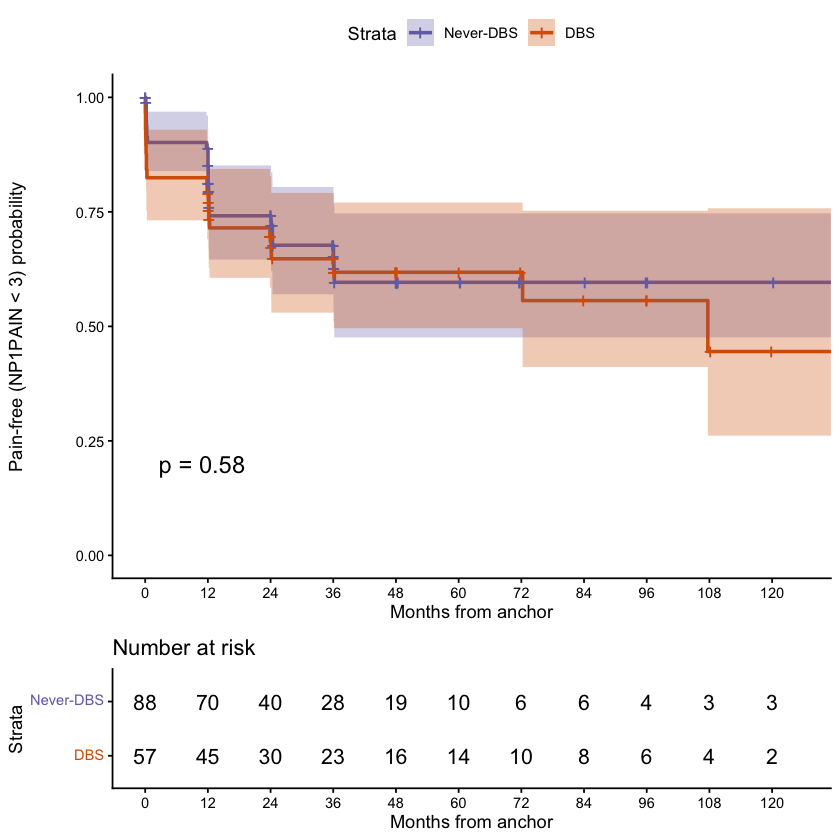

In [3]:
fit <- survival::survfit(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev)
print(summary(fit, times = c(6, 12, 24, 36, 48, 60)))

lr <- survival::survdiff(survival::Surv(event_time, event) ~ will_receive_dbs, data = ev)
print(lr)
cat("Log-rank p-value:", signif(1 - pchisq(lr$chisq, df = length(lr$n) - 1), 4), "\n")

p_km <- survminer::ggsurvplot(
  fit, data = ev,
  palette = c("#7570b3","#d95f02"),
  legend.labs = c("Never-DBS","DBS"),
  xlab = "Months from anchor", ylab = "Pain-free (NP1PAIN < 3) probability",
  risk.table = TRUE, break.x.by = 12, pval = TRUE, conf.int = TRUE,
  ggtheme = theme_classic(base_size = 11)
)
print(p_km)
ggplot2::ggsave(file.path(OUT_FIG, "Fig20_km_pain_worsening.png"),
                plot = p_km$plot, width = 7.5, height = 5, dpi = 300)

In [4]:
# Cox regression with baseline adjustments
base <- df %>% dplyr::arrange(PATNO, INFODT_orig) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, age_at_visit, SEX, LEDD, updrs3_score, NP1PAIN, NP1DPRS, NP1ANXS)
ev2 <- ev %>% dplyr::inner_join(base, by = "PATNO") %>% tidyr::drop_na()
cat("Cox n:", nrow(ev2), "\n")

cox <- survival::coxph(
  survival::Surv(event_time, event) ~ will_receive_dbs + age_at_visit + SEX +
    LEDD + updrs3_score + NP1PAIN + NP1DPRS + NP1ANXS,
  data = ev2
)
print(summary(cox))
cx_tbl <- broom::tidy(cox, conf.int = TRUE, exponentiate = TRUE)
print(cx_tbl)
save_table(cx_tbl, "cox_pain_worsening")

Cox n: 120 


Call:
survival::coxph(formula = survival::Surv(event_time, event) ~ 
    will_receive_dbs + age_at_visit + SEX + LEDD + updrs3_score + 
        NP1PAIN + NP1DPRS + NP1ANXS, data = ev2)

  n= 120, number of events= 41 

                           coef  exp(coef)   se(coef)      z Pr(>|z|)   
will_receive_dbsTRUE -1.201e-01  8.869e-01  3.475e-01 -0.345  0.72975   
age_at_visit         -1.757e-02  9.826e-01  1.946e-02 -0.903  0.36656   
SEX                   7.110e-02  1.074e+00  3.369e-01  0.211  0.83288   
LEDD                  9.676e-05  1.000e+00  5.098e-04  0.190  0.84945   
updrs3_score         -3.247e-02  9.680e-01  1.802e-02 -1.803  0.07146 . 
NP1PAIN               6.066e-01  1.834e+00  1.866e-01  3.251  0.00115 **
NP1DPRS               4.594e-01  1.583e+00  2.529e-01  1.817  0.06928 . 
NP1ANXS              -3.472e-01  7.067e-01  2.803e-01 -1.239  0.21549   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                     exp(coef) exp(-coef) lower .95 uppe

# A tibble: 8 × 7
  term                 estimate std.error statistic p.value conf.low conf.high
  <chr>                   <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 will_receive_dbsTRUE    0.887  0.348       -0.345 0.730      0.449      1.75
2 age_at_visit            0.983  0.0195      -0.903 0.367      0.946      1.02
3 SEX                     1.07   0.337        0.211 0.833      0.555      2.08
4 LEDD                    1.00   0.000510     0.190 0.849      0.999      1.00
5 updrs3_score            0.968  0.0180      -1.80  0.0715     0.934      1.00
6 NP1PAIN                 1.83   0.187        3.25  0.00115    1.27       2.64
7 NP1DPRS                 1.58   0.253        1.82  0.0693     0.964      2.60
8 NP1ANXS                 0.707  0.280       -1.24  0.215      0.408      1.22
